In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
import numpy as np
import pandas as pd


def remove_outliers_zscore(df, column, threshold=3):

    df_clean = df.copy()

    # Compute the Z-score for the specified column
    z_scores = np.abs(
        (df_clean[column] - df_clean[column].mean()) / df_clean[column].std())

    # Keep only rows where the absolute Z-score is below the threshold
    df_clean = df_clean[z_scores < threshold]

    return df_clean



In [35]:
df = pd.read_csv(r'C:\Users\greys\OneDrive\big-data-analytics\data\data1.csv')
df.head()

,sample,permeability(md),porosity (%),depth (ft),pressure(psi),production rate(bbl/day)
0,1,29.00,21.7,2699.7,1112.950964,370.575096
1,2,11.50,19.9,2717.1,3816.504868,369.718165
2,3,7.96,19.2,2729.9,119.233582,133.720583
3,4,24.00,22.1,2783.3,291.996216,104.202517
4,5,2.07,19.8,2817.7,3987.438445,121.171415


## 1. Remove Incomplete Samples

In [36]:
VALUE_COLS = ['depth (ft)', 'permeability(md)', 'porosity (%)', 'pressure(psi)']
prev_len = len(df)
df = df.dropna(subset=VALUE_COLS)
new_len = len(df)
num_removed_samples = prev_len - new_len
f'{num_removed_samples=}'

'num_removed_samples=6'

## 2. Remove samples with permeability outliers

In [37]:
prev_len = len(df)
df = remove_outliers_zscore(df, 'permeability(md)',threshold=1)
num_removed_samples = prev_len - len(df)
f'{num_removed_samples=}'

'num_removed_samples=8'

## 3. Feature Engineering

### MinMax Scaling

In [41]:
# Select only numerical columns for scaling
numerical_columns = df.select_dtypes(include=['number']).columns

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = df.copy(deep=True)
df_scaled[numerical_columns] = scaler.fit_transform(df_scaled[numerical_columns])
df_scaled.head()

,sample,permeability(md),porosity (%),depth (ft),pressure(psi),production rate(bbl/day)
2,0.000000,1.000000e+00,0.795556,0.155486,0.016692,0.272295
4,0.019417,2.600468e-01,0.822222,0.160802,1.000000,0.246719
5,0.029126,3.994947e-01,0.871111,0.161656,0.373821,0.380245
8,0.058252,1.720649e-02,0.448889,0.456615,0.143372,0.650623
9,0.067961,5.025149e-07,0.311111,0.559144,0.115413,0.349610


### PCA

In [42]:
# Drop rows with NaN values in selected columns
df_cleaned = df[VALUE_COLS].dropna()

# Apply PCA (reduce to 2 principal components for visualization)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_cleaned)

# Convert PCA results to a DataFrame
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,0.364604,-0.959071
1,0.789172,-0.063239
2,0.424968,-0.570249
3,-0.191512,-0.295111
4,-0.321887,-0.199522


## 4. Cross Plots

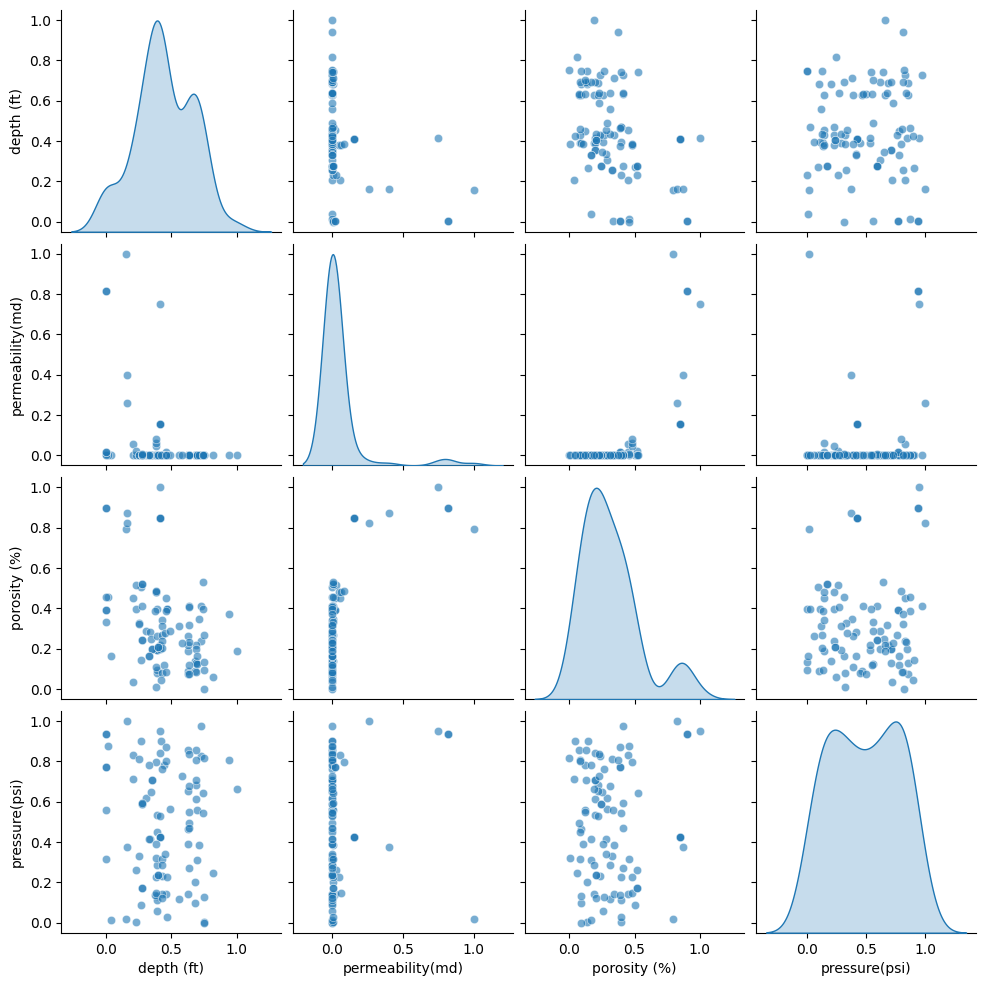

In [40]:
sns.pairplot(df[VALUE_COLS], diag_kind='kde',
             markers='o', plot_kws={'alpha': 0.6})


## 5. Determine the correlaƟon coefficients of the first three properƟes 

In [43]:
correlation_before = df[VALUE_COLS].corr()
correlation_pca = df_pca.corr()
correlation_scaled = df_scaled[VALUE_COLS].corr()

In [ ]:
correlation_before

,depth (ft),permeability(md),porosity (%),pressure(psi)
depth (ft),1.000000,-0.339670,-0.412910,-0.024556
permeability(md),-0.339670,1.000000,0.687336,0.135998
porosity (%),-0.412910,0.687336,1.000000,0.042979
pressure(psi),-0.024556,0.135998,0.042979,1.000000


In [45]:
correlation_scaled

,depth (ft),permeability(md),porosity (%),pressure(psi)
depth (ft),1.000000,-0.339670,-0.412910,-0.024556
permeability(md),-0.339670,1.000000,0.687336,0.135998
porosity (%),-0.412910,0.687336,1.000000,0.042979
pressure(psi),-0.024556,0.135998,0.042979,1.000000


### 6. Discuss whether the correlation coefficients capture the dependency in this example.


Correlation depends on relative changes, not absolute changes. 
Therefore we see that scaling the dataset resulted in 0 difference in correlation.
Additionally, applying PCA to the data showed completely different correlations, this is because
PCA as a process is non-linear and affects the relative relationship of the features. The scaled correlation 
captures the dependency in the data, however the PCA'd correlation does not.